# Final Pc Problem - Orbiting Super Massive Black Hole (SMBH) simulation to determine if the CDM spike evaporates

## Final pc Problem context
The final parsec problem is one of the main open questions in modern cosmology. With the Cold Dark Matter (CDM) model of Dark Matter we can not explain how the Super Massive Black Holes (SMBH) of the center of galaxies lose orbital energy to become closer (harden) until they coalesce. 

When the two SMBH are at 10 pc or more, they can eject stars and gas to harden, when the distance is 0.2 pc or less, the binary loses orbital energy through the emission of gravitational waves (GW). Nevertheless, at 1 pc there is no explanation on how the binary could harden (the gw are not strong enough and there is no sufficient stars and gas to eject). The CDM spike could provide an explanation, the spike is a high concentration of DM for which there is evidence to exist in the center of galaxies (around the SMBH), this spike would trail the SMBH in its orbital motion, and drag him along. The problem is that the spike would backreact, absorbing this orbital energy would disrupt the spike until it evaporates. 
## Proposed solution to the PC problem
In the paper by Gonzalo Alonso-Álvarez et al, they propose Self-Interacting Dark Matter (SIDM) to solve this problem. With interacting DM, the halo would be thermalized, and the spike could be replenished so it continues to harden the binary until it reaches the GW region of influence. Solving the final Pc problem.

## Purpose of the Jupyter notebook
The purpose of this jupyter notebook is to make a toy model script, where we simulate a spike of DM, to see if it evaporates. Also to prove that it hardens the binary before it is disrupted.

We use the python package rebound which uses newtonian mechanics, is a good first approximation to see if the spike dissolves, and the binary hardens.

Simulating the orbit of two black holes, and adding a spike of CDM (a small number of dm particles which we assume to contain the whole mass of the spike) and see if the spike dissolves. The CDM only interacts by gravity.

# Importing packages and defining the system

- Rebound: We import the rebound package which uses newtonian mechanics in to make a N-body simulation.
- Numpy: For array treatment
- Random: For the definition of the spike
- Pyplot: to graphicate our results and system in plots.
- Os: For file management
- Imageio.v3: For joining the frames to form the video simulation

We use rebound to define the system ```rebound.Simulation()```. We define the units with ```sim.units()```, and add the BH with ```sim.add(m=mass, a=major_axis)```, defining the second BH to be in a perfect circular orbital motion with respect to the first BH.


In [14]:
import rebound
import numpy as np
import random
import matplotlib.pyplot as plt
import os
import imageio.v3 as iio

# Create an empty universe
sim = rebound.Simulation()
sim.units = ('yr', 'AU', 'Msun')

# We add the BHs to the simulation
# We define the parameters of the BHs
M_1 = 3e9
q = 1
M_2 = q * M_1
M_total = M_1 + M_2

# We add them
sim.add(m=M_1)
sim.add(m = M_2, a = 206265)

# We define the BH
black_hole_1 = sim.particles[0]
black_hole_2 = sim.particles[1]

# Definition of the DM Spike

We set the parameters of the spike (size, number of particles, and total mass). And use the random package to give the DM particles a uniform random distribution in an spherical shell.

In [15]:
# Define the DM spike
N_particles = 60
M_spike_total = 0.1*M_1
m_single_dm = M_spike_total / N_particles
radius_spike = 400000
bh_distance = []

# Shifts the entire reference frame so the COM is at the origin, to define the DM orbiting the CoM
sim.move_to_com()

print(f"Generating {N_particles} DM particles in the spike with mass {m_single_dm:.2e} Msun each...")
random.seed(0)


# The DM particles are located using a random uniform distribution
for i in range(N_particles):
    # pick a random distance to the black hole
    r = random.uniform(1000, radius_spike)
    
    # Pick random angles to make it a 3D sphere
    random_tilt = random.uniform(0, np.pi)
    random_phi = random.uniform(0, 2*np.pi)
    
    x = r * np.sin(random_tilt) * np.cos(random_phi)
    y = r * np.sin(random_tilt) * np.sin(random_phi)
    z = r * np.cos(random_tilt)
    # Velocity for rotating the CoM
    v_circ = np.sqrt(sim.G * M_total / r)
    
    v_x = -v_circ * np.sin(random_tilt)
    v_y = v_circ * np.cos(random_tilt)
    
    #Add the particles as rotating the CoM
    
    # Add the particles
    sim.add(m = m_single_dm, x=x, y=y, vx=v_x, vy = v_y)
    
    
print("Spike succesfully created")

Generating 60 DM particles in the spike with mass 5.00e+06 Msun each...
Spike succesfully created


# Frame definition

We define the directory of where we will store the frames, with ```os.makedirs()```.

Then we define a python fuction, that given the simulation (state of the system), and the frame number, creates a plot of the system in a 2D cross section ignoring the z direction, and fixing the origin in the first BH. This are going to be our frames.

In [16]:
os.makedirs("spike_frames", exist_ok=True)

# Shifts the entire reference frame so the COM is at the origin
sim.move_to_com()

def frame(simulation, frame_number):
    # Get X and Y coordinates for Dark Matter (skipping the first 2 particles)
    x_dm = np.array([b.x for b in simulation.particles[2:]]) 
    y_dm = np.array([b.y for b in simulation.particles[2:]]) 
    
    # We get the coordinates of the BH
    x_bh = np.array([b.x for b in simulation.particles[:2]]) 
    y_bh = np.array([b.y for b in simulation.particles[:2]]) 
    
    #Create the graph
    plt.style.use('dark_background') 
    plt.figure(figsize=(8,8))
    
    # Plot DM as tiny blue dots, and BH as big red stars
    plt.scatter(x_dm, y_dm, s=10, color='cyan', alpha=0.6, label='CDM Particles')
    plt.scatter(x_bh, y_bh, s=150, color='red', marker='*', label='SMBH')
    
    #Lock the camara frame so we can compare before/after accurately
    plt.xlim(-500000, 500000)
    plt.ylim(-500000, 500000)
    plt.title(f"Simulation Time: {simulation.t:,.0f} Years", fontsize=14)
    plt.legend(loc='upper right')
    
    filename = f"spike_frames/frame_{frame_number:04d}.png"
    
    plt.savefig(filename, dpi=100)
    
    plt.close() #to remove image from ram

# Collisions 
We turn on collisions, so that when a particle passes too close to de BH it is absorbsed. The radius for absorbtion will be the Schwarzchild radius, which is $$R_{Sch} = 2GM_{bh}/c^2$$

In [17]:
# Schwarzchild radius
c = 2.99792458e8 * 6.68459e-12 * (3600 * 24 * 365.2425)
G = 6.674e-11 * (6.68459e-12) ** 3 * (3600 * 24 * 365.2425) ** 2
M = M_1 * 1.989e30
R_sch = 2 * G * M / c**2

print(f'The Schwarzchild radius is {R_sch} ua')
# We give a collision radius to the BH
sim.particles[0].r = R_sch
sim.particles[1].r = R_sch

# Turn the rebound collision detector
sim.collision = "direct"

# Tell rebound that if there is a collision then merge the particles
sim.collision_resolve = "merge"

The Schwarzchild radius is 59.238711673042346 ua


# Simulation
In the next cell we define the length of the simulation and the number of frames.

We let the system evolve with ```sim.integrate(time)```. And in a for loop, save each frame with the ````frame()```` function. We also save the distance between the black holes in the bh_distance array.

In [18]:
# Execute the simulation
N_years = 20000
N_frames = 600
t_array = np.linspace(0, N_years, N_frames)
Delta_time = N_years/N_frames
print(f"Running the simulation for {N_years} years")

for i in range(N_frames):
    next_time = sim.t + Delta_time
    sim.integrate(next_time)
    
    #save the frame
    frame(sim, i)
    
    # Print progress so you know it hasn't frozen
    if i % 100 == 0:
        print(f"Rendered frame {i} / {N_frames}")
        
    # Save the distances between blackhole
    bh_distance.append(black_hole_1 ** black_hole_2)
    
print("Simulation complete")

    

Running the simulation for 20000 years
Rendered frame 0 / 600
Rendered frame 100 / 600
Rendered frame 200 / 600
Rendered frame 300 / 600
Rendered frame 400 / 600
Rendered frame 500 / 600
Simulation complete


# Distance of the SMBH vs time

We create a plot of the distance between the black holes vs the time passed in the simulation. To see how the binary gets closer with time due to the ejection of DM particles, until the spike evaporates. Whence, the distances stalls, and hits a plateau.

Text(0, 0.5, 'Distance between the BHs (pc)')

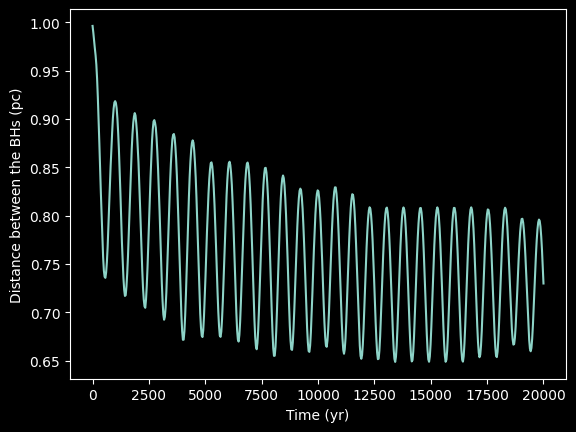

In [19]:
# We convert to parsec
bh_distance = np.array(bh_distance) / 206265
plt.plot(t_array, bh_distance)
plt.xlabel('Time (yr)')
plt.ylabel('Distance between the BHs (pc)')

Doing the temporal average of this graphic so that it is smoother (the peaks are probably due to the orbit not being circular, but elliptical)

Text(0, 0.5, 'Distance between the BHs (pc)')

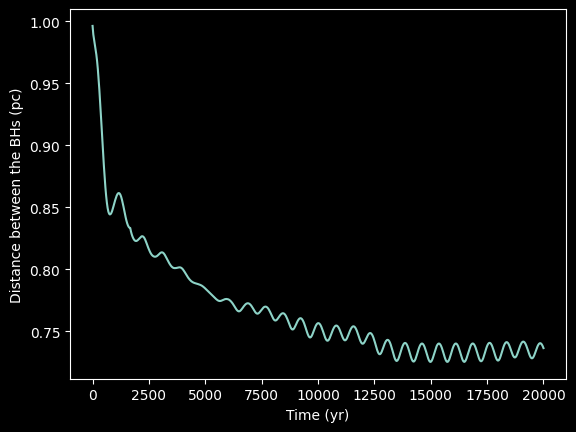

In [20]:
# An algorithm that averages the distance with the adjacent data points
avg_distance = [bh_distance[0]]
for i in range(1, len(bh_distance)):
    a = min(i, 50)
    sum = 0
    for g in range(int(a)):
        sum += bh_distance[i - g]
    
    avg_distance_new = sum / a
    avg_distance.append(avg_distance_new)

# Plot the distance
plt.plot(t_array, avg_distance)
plt.xlabel('Time (yr)')
plt.ylabel('Distance between the BHs (pc)')


# Video Generation

We use the ````os.listdir()```` function to recover all the frames, then we sort them by their order. Afterwards, we employ the ````io.imread()```` function to assemble the frames and create the video.

In [21]:
frame_folder = "spike_frames"
video_filename = "dark_matter_spike.mp4"
fps = 15

image_files = [f for f in os.listdir(frame_folder) if f.endswith('.png')]
image_files.sort() # to sort the frames

# Create the video

with iio.imopen(video_filename, "w", plugin="pyav") as writer:
    
    for filename in image_files:
        file_path = os.path.join(frame_folder, filename)
        
        # Read the image data
        image_data = iio.imread(file_path)
        
        # Strip the alpha channel (RGBA -> RGB)
        image_data = image_data[:, :, :3]
        
        # Write it to the video stream, explicitly telling it this is ONE frame
        writer.write(image_data, codec="libx264", fps=fps, is_batch=False)

print(f"Success! Your simulation movie is saved as: {video_filename}")

Success! Your simulation movie is saved as: dark_matter_spike.mp4


We show the video

In [22]:
from IPython.display import Video

# Mostramos el vídeo interactivo en el notebook
Video(video_filename, embed=True, width=700)